In [1]:
import pandas as pd 

df=pd.read_csv("../data/raw/dataset-diabete-6ab953aea55fc643490108.csv")

df.describe()



,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [ ]:
df.info

(768, 9)

In [33]:

df.isnull().sum()
df.duplicated().sum()
df[df.duplicated()]


,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


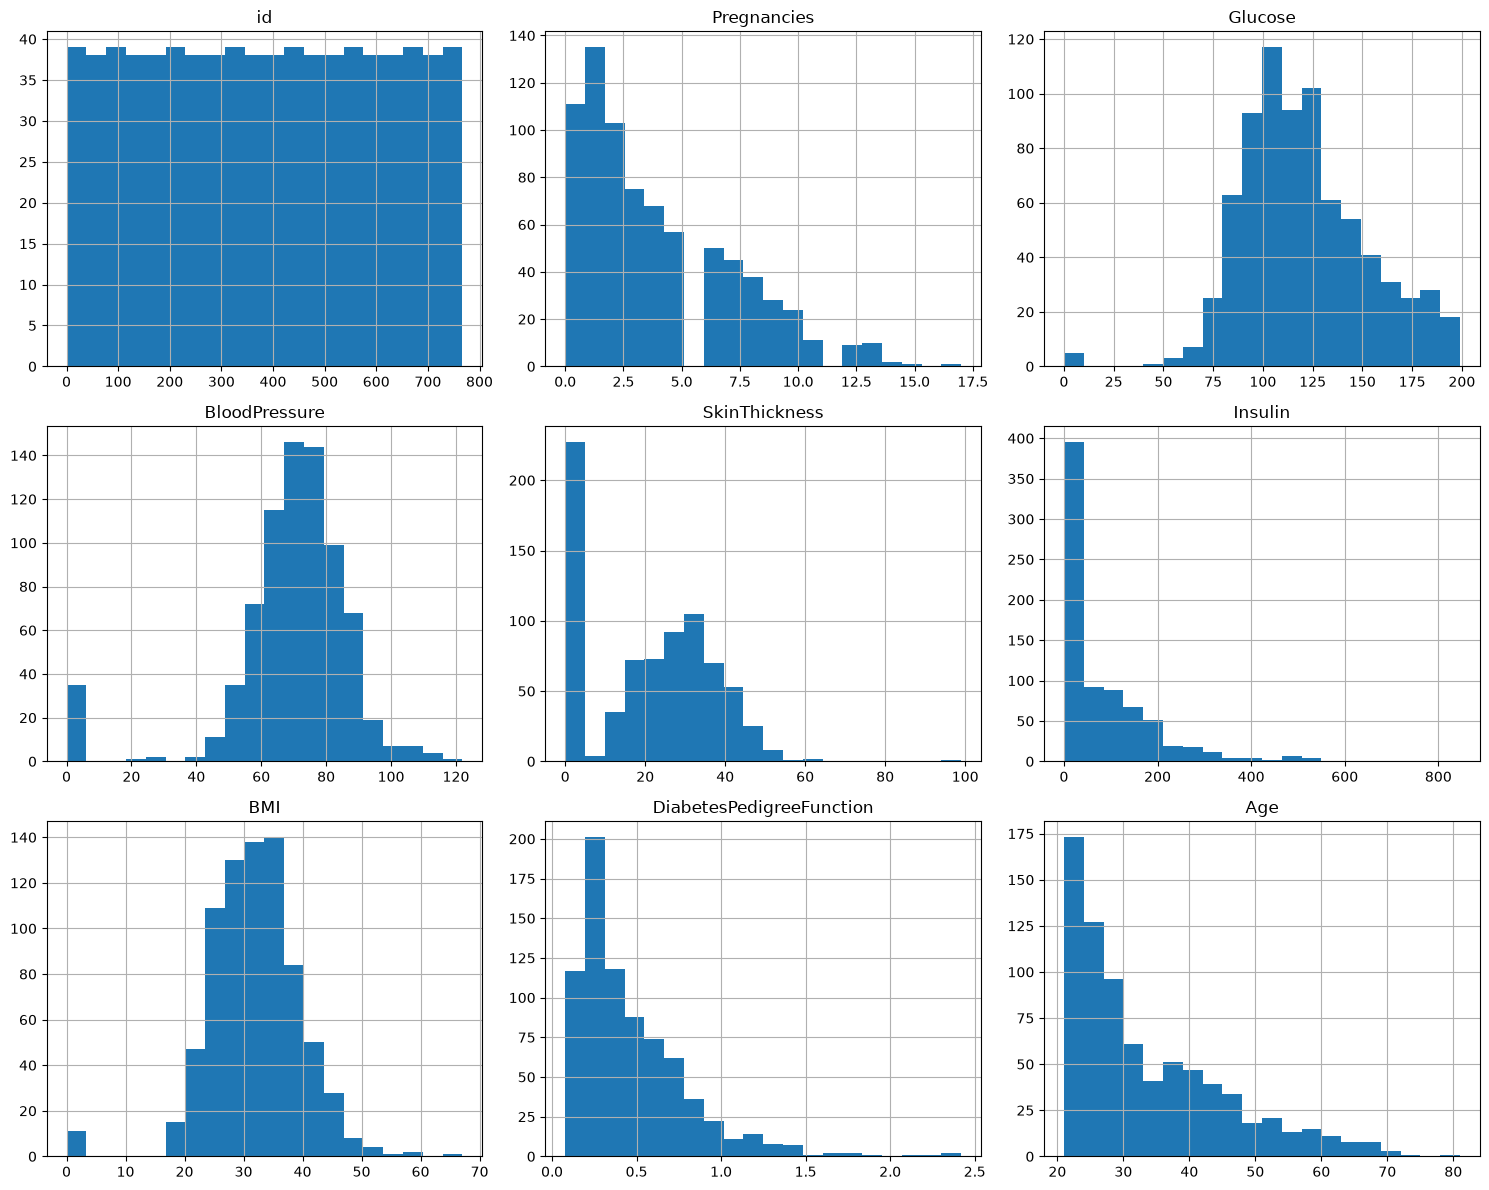

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

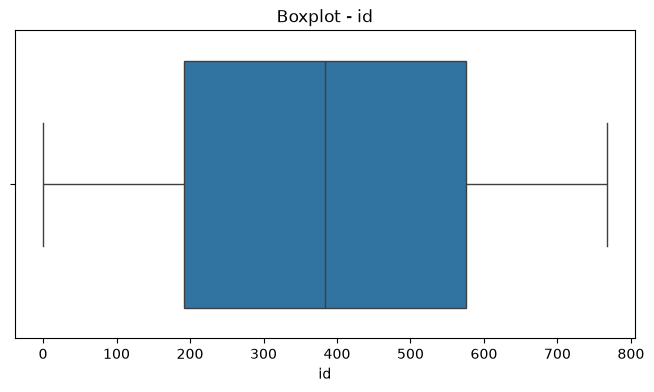

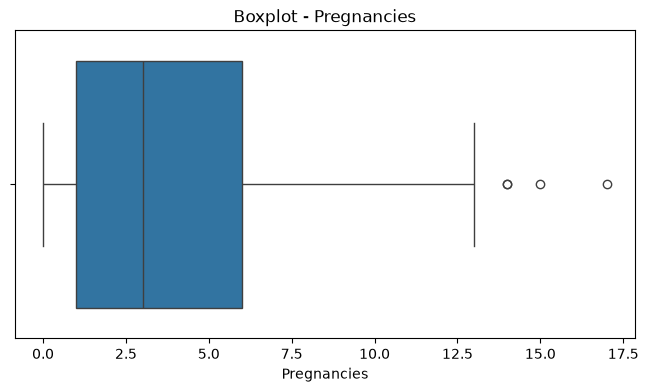

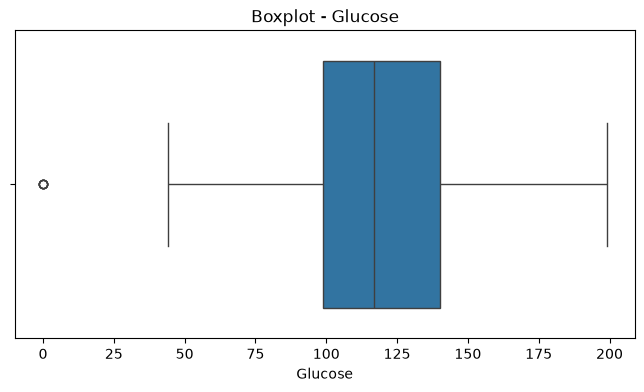

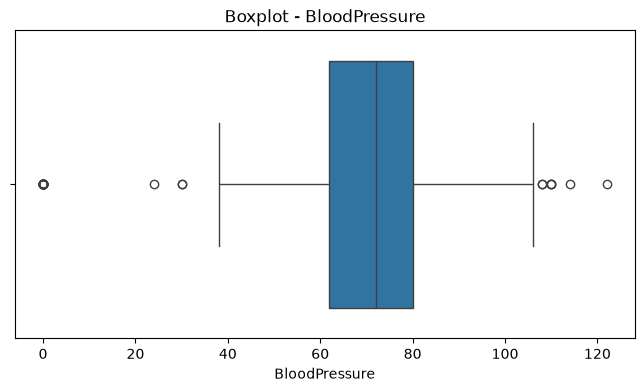

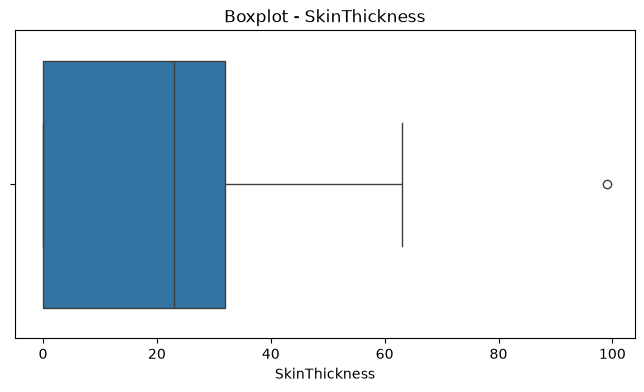

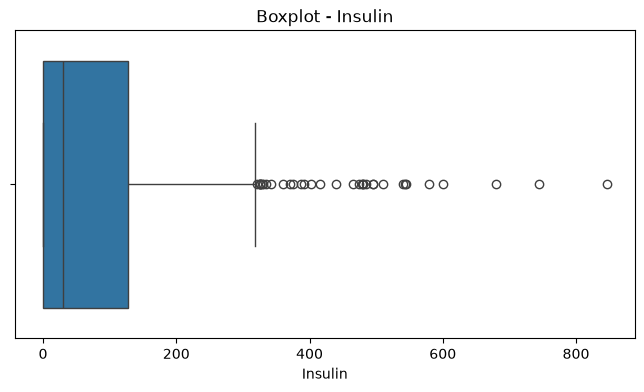

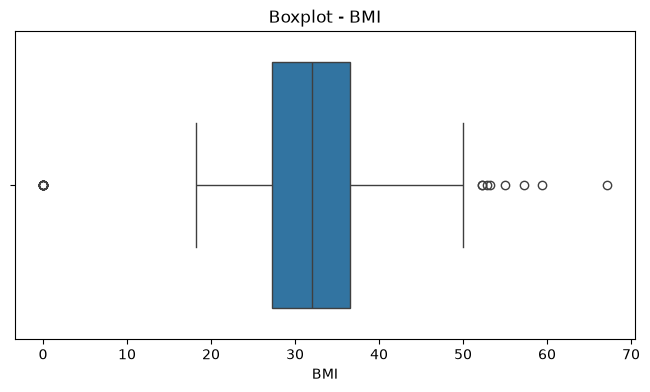

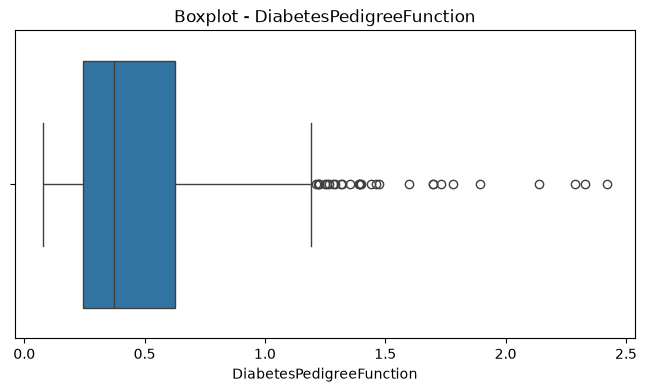

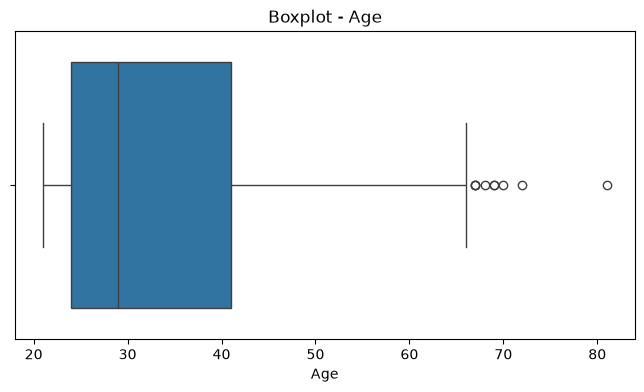

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

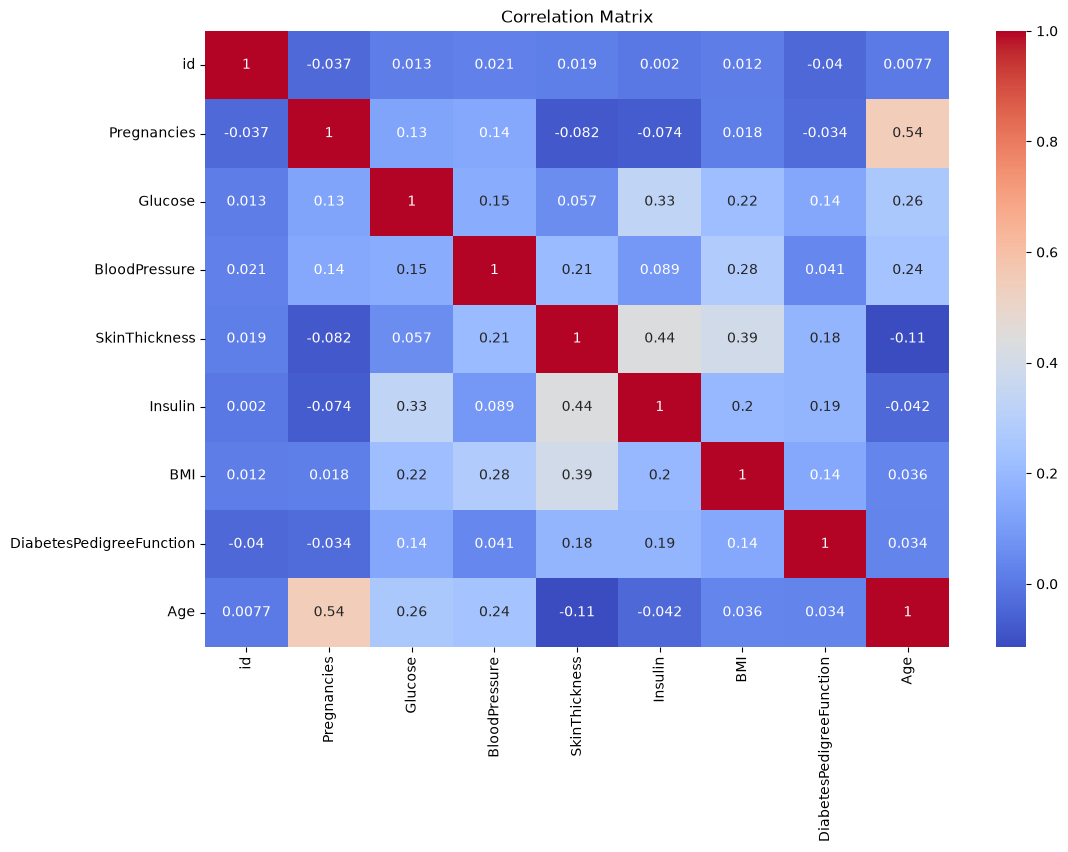

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction']

# 1. Remplacer les 0 b NaN f l-bidaya
df[cols]=df[cols].replace(0,np.nan)

# 2. Stikhdam IQR bach n-lqaou les outliers w n-rddouhom NaN
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    print("upper_bound",upper_bound)
    print("lower_bound",lower_bound)

    df.loc[df[col] > upper_bound, col] = upper_bound
    df.loc[df[col] < lower_bound, col] = lower_bound
    count = (df[col] < upper_bound).sum()
    print(count)

imputer = KNNImputer(n_neighbors=5)
df[cols] = imputer.fit_transform(df[cols])




upper_bound 204.0
lower_bound 36.0
763
upper_bound 104.0
lower_bound 40.0
721
upper_bound 57.0
lower_bound 1.0
538
upper_bound 360.625
lower_bound -94.375
370
upper_bound 50.25
lower_bound 13.849999999999998
749
upper_bound 1.2
lower_bound -0.32999999999999996
739


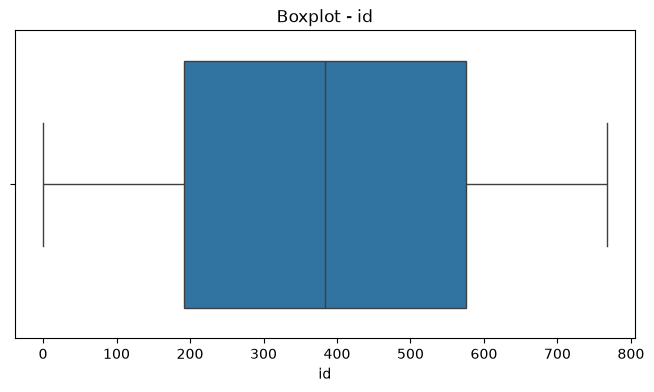

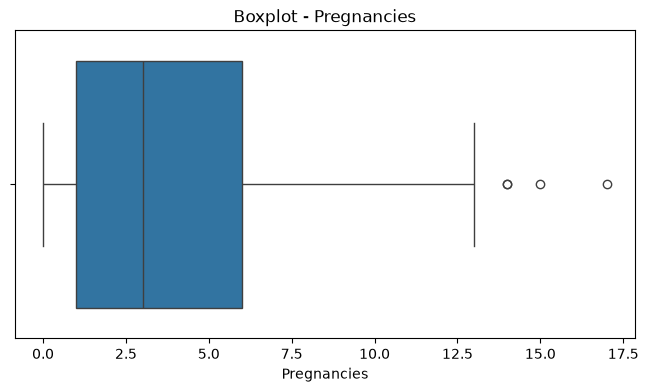

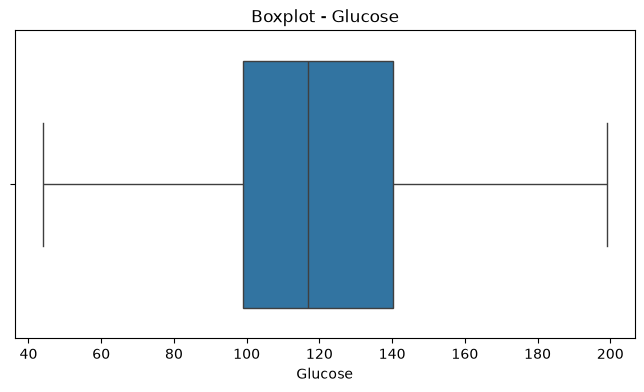

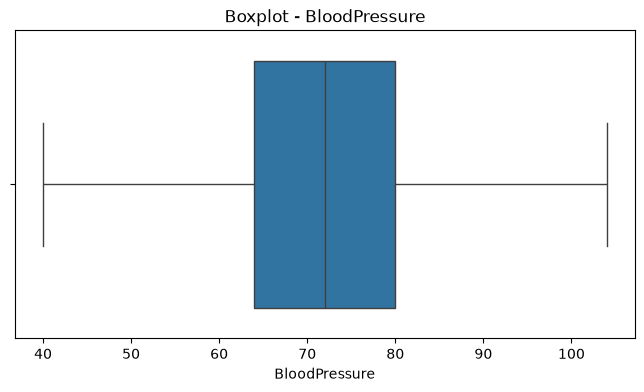

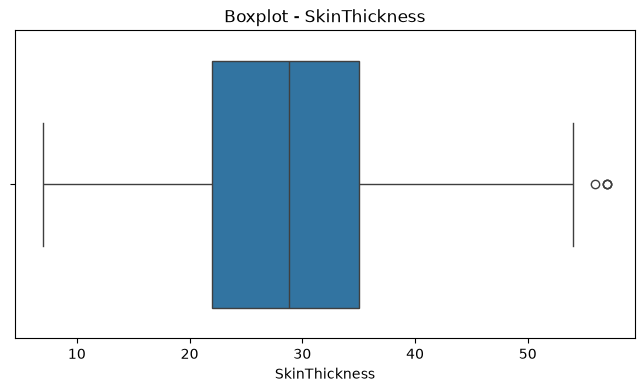

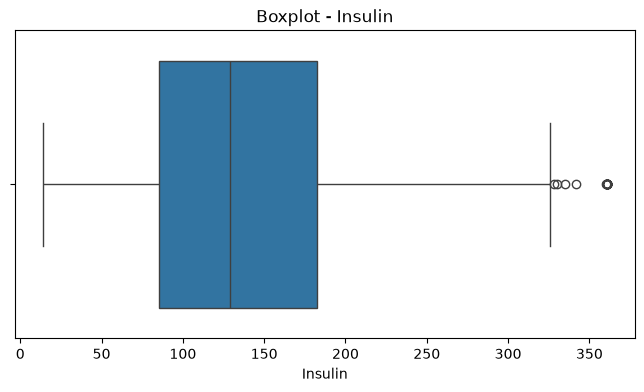

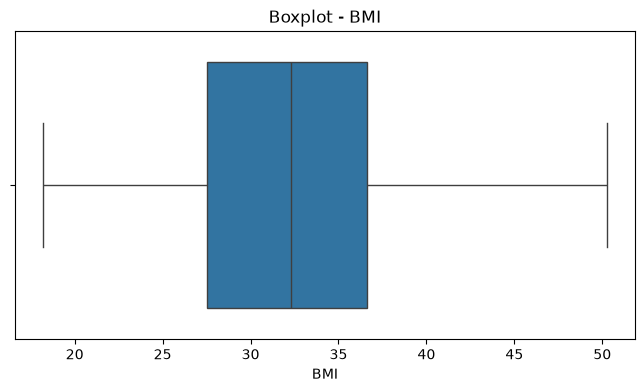

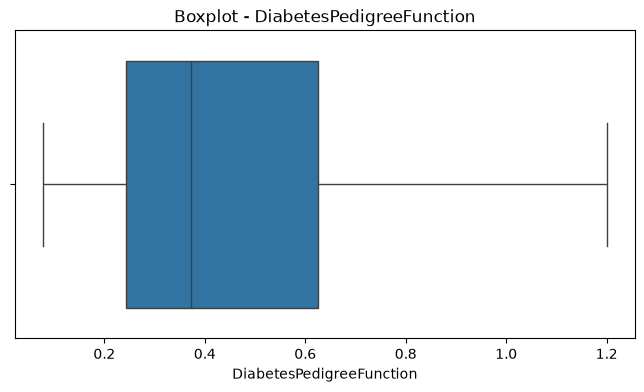

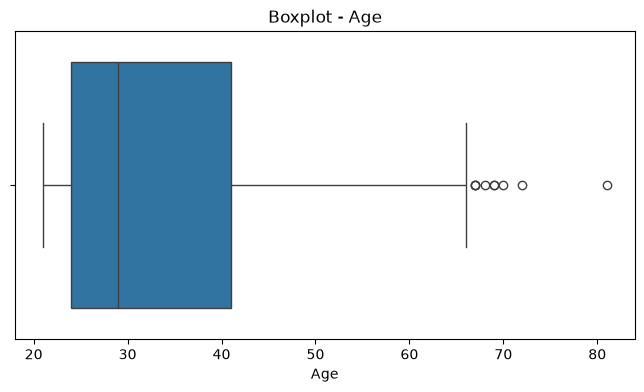

In [38]:


import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

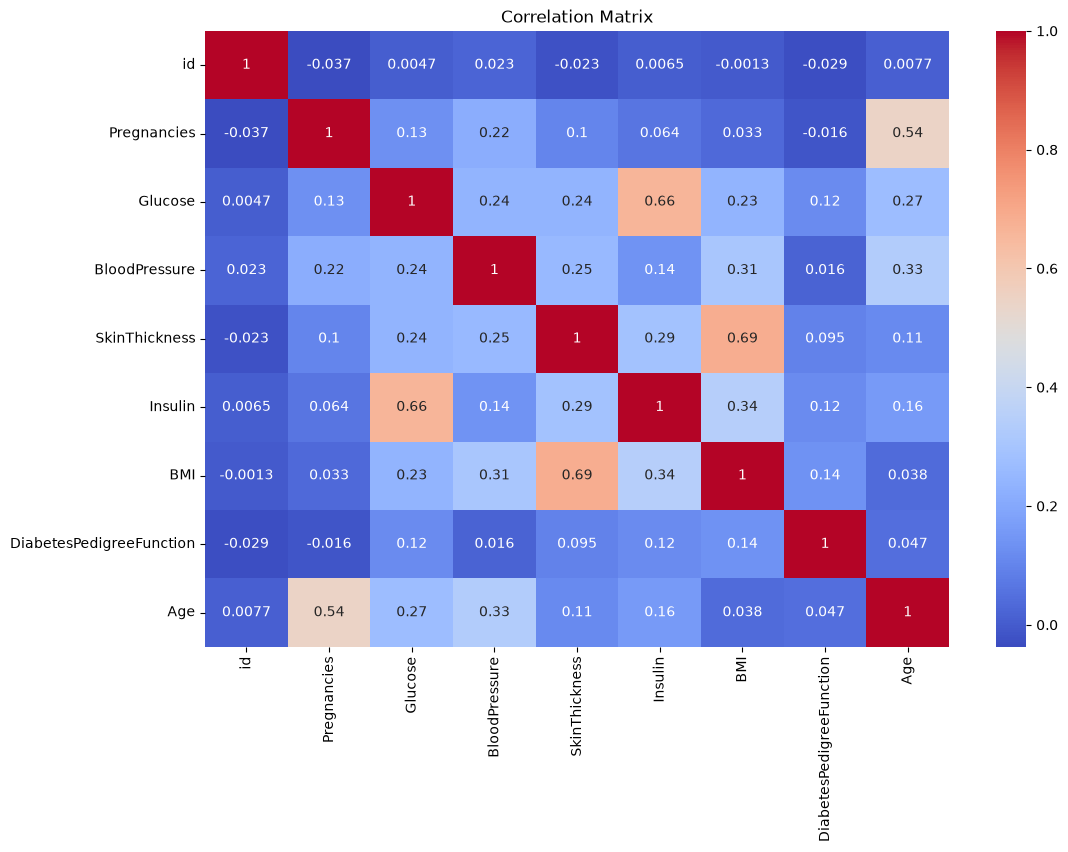

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

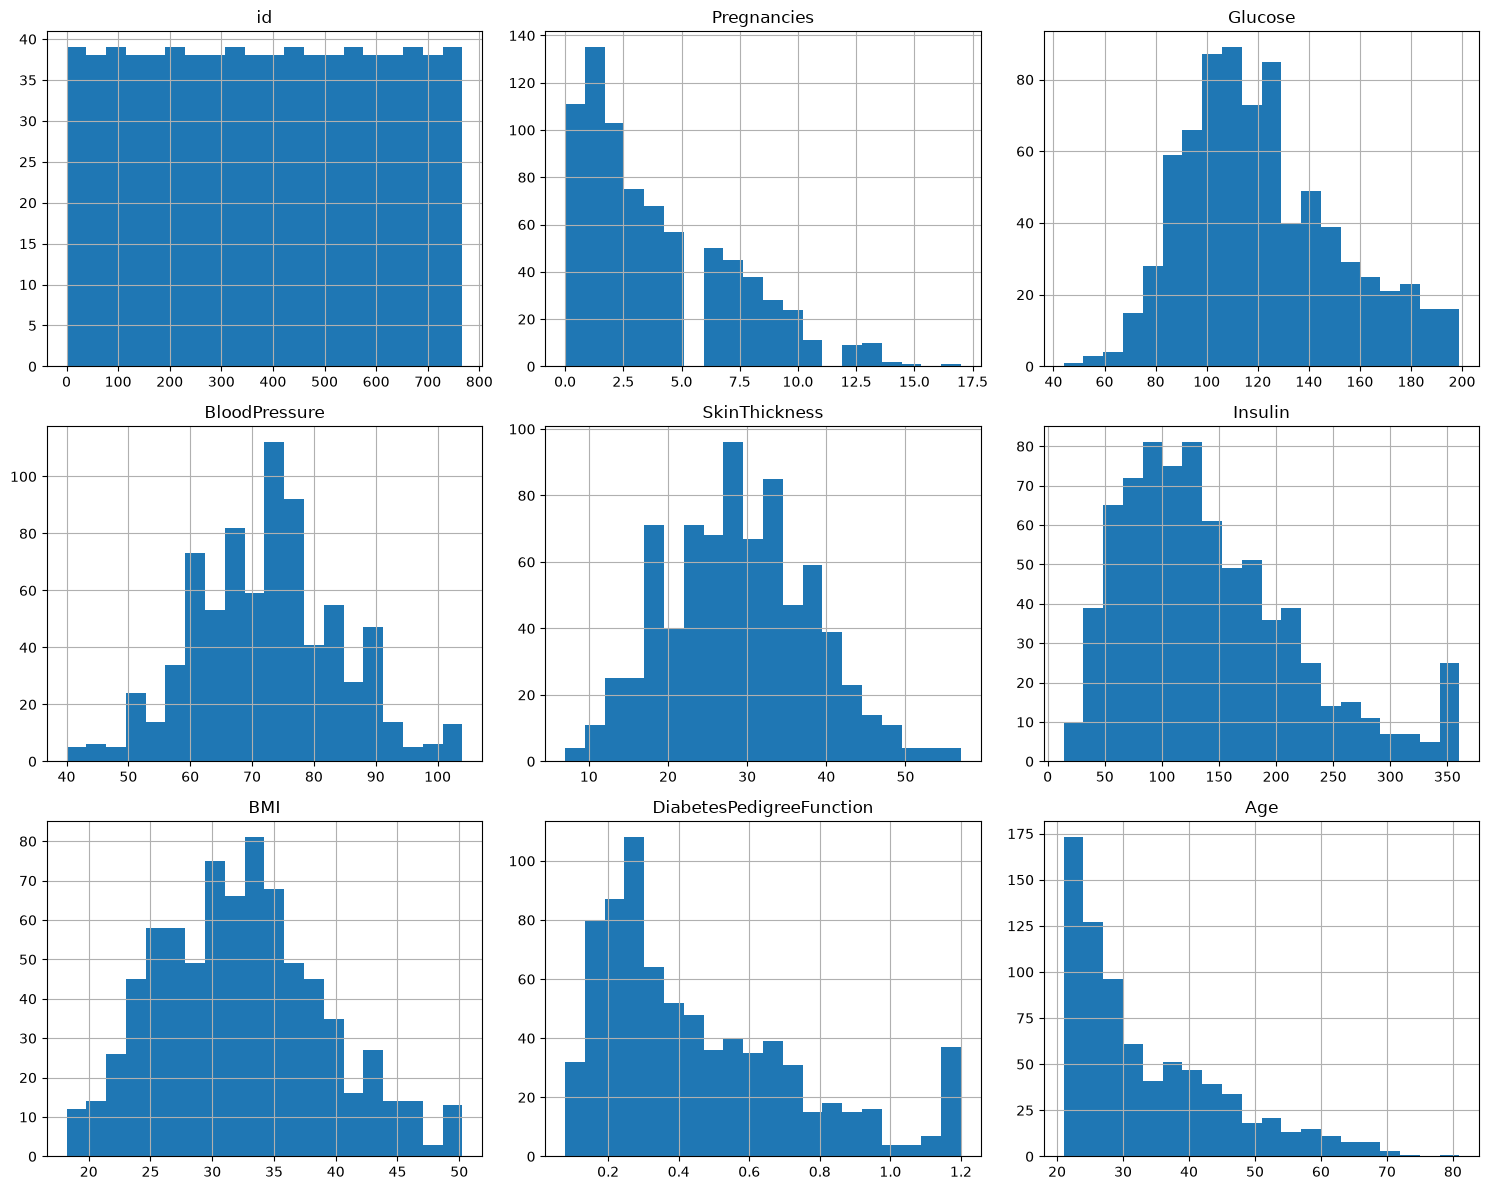

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

In [41]:
df = df.round(2)
df = df.drop(columns=["id"])
df.to_csv('../data/processed/pima_diabetes_cleaned.csv', index=False)